MAE: 133.46337527982791
R2 Score: 0.8970742858859222
✅ Model saved successfully!


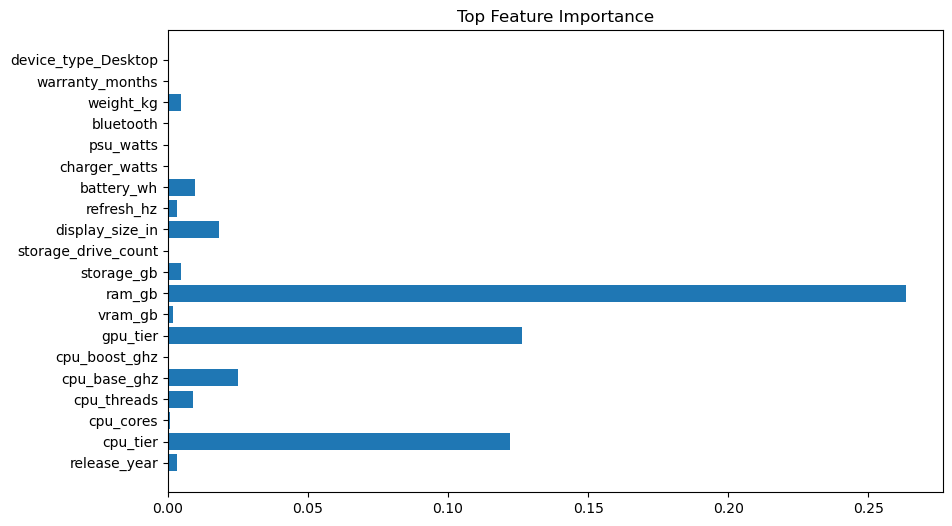

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor
import joblib
import matplotlib.pyplot as plt


df = pd.read_csv(r"D:\DATASCIENCE\PROJECTS\Electronics Set Analysis\cleaned_computer_prices.csv")  

df = df.dropna()  

X = df.drop("price", axis=1)
y = df["price"]


categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


joblib.dump(model, "price_prediction_model.pkl")

print("✅ Model saved successfully!")


xgb_model = model.named_steps['regressor']

ohe = model.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat = ohe.get_feature_names_out(categorical_cols)

all_features = list(numerical_cols) + list(encoded_cat)

# Plot
importances = xgb_model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(all_features[:20], importances[:20])  # top 20
plt.title("Top Feature Importance")
plt.show()